# Project 6: Simple Neural Network Forward Propagation



## Task 1 — Load and Prepare the Dataset

The Iris data contains sepal length, sepal width, petal length, and petal width. These four values are used as the input to the neural network.

In [15]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
# Read the Iris dataset
iris_data = load_iris()
features = iris_data.data
labels = iris_data.target

print("Number of records:", features.shape[0])
print("Number of input features:", features.shape[1])
print("Flower classes:", iris_data.target_names)

Number of records: 150
Number of input features: 4
Flower classes: ['setosa' 'versicolor' 'virginica']


In [17]:
# Standardize the four input measurements
normalizer = StandardScaler()
features_scaled = normalizer.fit_transform(features)

# Convert the three class labels into one-hot vectors
labels_one_hot = np.eye(3)[labels]

# Keep 20% of the observations for testing
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled,
    labels_one_hot,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 120
Testing records: 30


## Task 2 — Create the Neural Network

A small two-layer network is used for this demonstration:

- **Input layer:** 4 values corresponding to the flower measurements
- **Hidden layer:** 6 neurons using ReLU
- **Output layer:** 3 neurons representing the three Iris species

During forward propagation, each layer calculates a weighted sum and adds a bias. The result is then passed through its activation function.

In [18]:
# Fix the random values so the result can be reproduced
np.random.seed(42)

n_inputs = 4
n_hidden = 6
n_outputs = 3

# Parameters connecting the input and hidden layers
weights_hidden = np.random.randn(n_inputs, n_hidden) * 0.01
bias_hidden = np.zeros((1, n_hidden))

# Parameters connecting the hidden and output layers
weights_output = np.random.randn(n_hidden, n_outputs) * 0.01
bias_output = np.zeros((1, n_outputs))

print("Input → Hidden weights:", weights_hidden.shape)
print("Hidden → Output weights:", weights_output.shape)

Input → Hidden weights: (4, 6)
Hidden → Output weights: (6, 3)


### Forward propagation

For each layer, the basic calculation is:

**Z = XW + b**

The resulting value is then transformed by an activation function before being passed to the next layer.

In [19]:
def relu(value):
    """Keep positive values and replace negative values with zero."""
    return np.maximum(0, value)


def softmax(value):
    """Convert output scores into probabilities."""
    shifted = value - np.max(value, axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)


def run_forward_pass(data):
    # First layer: input data to hidden neurons
    hidden_input = data @ weights_hidden + bias_hidden
    hidden_output = relu(hidden_input)

    # Second layer: hidden neurons to class scores
    final_input = hidden_output @ weights_output + bias_output
    probabilities = softmax(final_input)

    return hidden_output, probabilities


hidden_values, class_probabilities = run_forward_pass(X_test)

## Task 3 — Apply Activation Functions and View Predictions

ReLU is used in the hidden layer to add non-linearity. Softmax is used at the output because the network must choose among three possible flower classes.

In [20]:
# Select the class with the largest predicted probability
predicted_ids = np.argmax(class_probabilities, axis=1)
actual_ids = np.argmax(y_test, axis=1)

print(f"{'No.':<6}{'Actual':<15}{'Predicted':<15}")
print("-" * 36)

for index in range(min(10, len(X_test))):
    actual_name = iris_data.target_names[actual_ids[index]]
    predicted_name = iris_data.target_names[predicted_ids[index]]
    print(f"{index + 1:<6}{actual_name:<15}{predicted_name:<15}")

accuracy = np.mean(predicted_ids == actual_ids) * 100
print(f"\nForward-pass accuracy: {accuracy:.2f}%")

No.   Actual         Predicted      
------------------------------------
1     versicolor     versicolor     
2     setosa         setosa         
3     virginica      versicolor     
4     versicolor     versicolor     
5     versicolor     versicolor     
6     setosa         setosa         
7     versicolor     versicolor     
8     virginica      versicolor     
9     versicolor     versicolor     
10    versicolor     versicolor     

Forward-pass accuracy: 60.00%


In [21]:
# Show the probability distribution for one test flower
sample = 0
print("Flower:", iris_data.target_names[actual_ids[sample]])
print("Class probabilities:")

for name, probability in zip(iris_data.target_names, class_probabilities[sample]):
    print(f"  {name}: {probability:.4f}")

Flower: versicolor
Class probabilities:
  setosa: 0.3333
  versicolor: 0.3333
  virginica: 0.3333


# Visualization: Activation Function Outputs

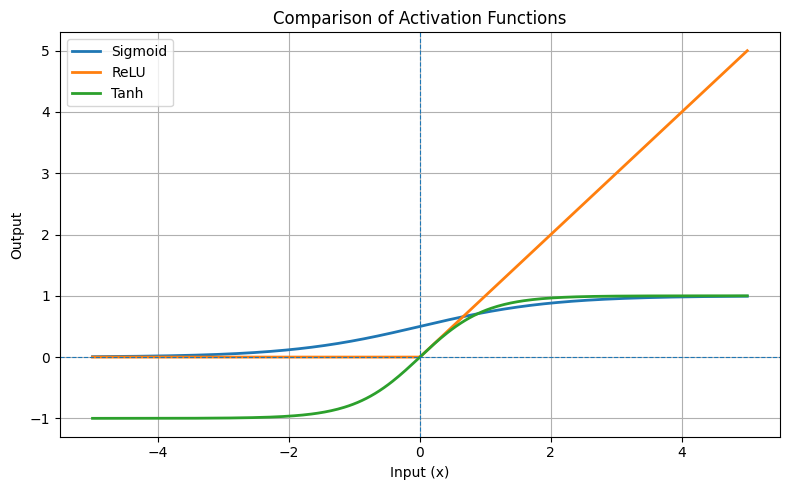

In [22]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 300)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh_fn(z):
    return np.tanh(z)

def relu_fn(z):
    return np.maximum(0, z)

plt.figure(figsize=(8, 5))

plt.plot(x, sigmoid(x), label='Sigmoid', linewidth=2)
plt.plot(x, relu_fn(x), label='ReLU', linewidth=2)
plt.plot(x, tanh_fn(x), label='Tanh', linewidth=2)

plt.axhline(0, linewidth=0.8, linestyle='--')
plt.axvline(0, linewidth=0.8, linestyle='--')

plt.title('Comparison of Activation Functions')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Result

The Iris measurements were successfully passed through a manually constructed neural network. The hidden layer transformed the inputs with ReLU, while the output layer converted the final scores into probabilities using Softmax. The class with the highest probability was taken as the predicted species.

Since this activity only demonstrates forward propagation, the weights are not learned from the training data. Therefore, the predictions are not expected to have the accuracy of a trained classifier. Backpropagation and weight updates would be required for the network to learn useful parameter values.